# DX799 Week 4: Logistic Regression and Feature Scaling

## Research Question

**Which county-level structural characteristics are associated with partisan direction across presidential election years, and what do those relationships add to our understanding of broader county-level political polarization?**

The capstone examines political polarization through two related but distinct outcomes: `vote_margin`, which measures the direction and magnitude of the two-party presidential vote margin, and `pol_intensity`, which measures county one-sidedness or political intensity regardless of partisan direction.

Weeks 1–3 modeled the continuous `vote_margin` outcome using different linear-regression approaches. Week 4 applies logistic regression, which requires a categorical outcome, by using the sign of `vote_margin` to represent partisan direction: 0 indicates the Democratic direction and 1 indicates the Republican direction.

The purpose is not simply to classify counties by party. Instead, this analysis tests whether the structural factors identified in the earlier continuous vote-margin models—education, economic structure, race composition, rural-urban geography, and election year—also help explain which direction county political outcomes take. These results will then be interpreted alongside the separate `pol_intensity` measure as part of the broader analysis of county-level political polarization.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

# Load the same RUCC-enabled county-year panel used in Weeks 1–3
data_path = Path(
    "../01_SOURCE_DATA/DX799_county_year_panel_2012_2024_RUCC_n12432.csv"
)

county_panel_df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("File:", data_path.name)
print("Observed shape:", county_panel_df.shape)

# Variables needed for the Week 4 analysis
required_columns = [
    "year",
    "county_fips",
    "dem_share",
    "rep_share",
    "vote_margin",
    "pol_intensity",
    "advanced_degree_pct",
    "median_income",
    "white_pct",
    "rural_urban_code"
]

missing_required = [
    column for column in required_columns
    if column not in county_panel_df.columns
]

if missing_required:
    raise ValueError(
        f"Required columns are missing: {missing_required}"
    )

print("\nRequired-column check: PASS")

print("\nElection years:")
print(sorted(county_panel_df["year"].unique()))

print("\nUnique counties:")
print(county_panel_df["county_fips"].nunique())

print("\nDuplicate county-year records:")
print(
    county_panel_df
    .duplicated(subset=["county_fips", "year"])
    .sum()
)

print("\nMissing values in Week 4 variables:")
week4_missing = (
    county_panel_df[required_columns]
    .isna()
    .sum()
)

display(
    week4_missing.to_frame("missing_count")
)

Dataset loaded successfully.
File: DX799_county_year_panel_2012_2024_RUCC_n12432.csv
Observed shape: (12430, 24)

Required-column check: PASS

Election years:
[np.int64(2012), np.int64(2016), np.int64(2020), np.int64(2024)]

Unique counties:
3116

Duplicate county-year records:
0

Missing values in Week 4 variables:


,missing_count
year,0
county_fips,0
dem_share,0
rep_share,0
vote_margin,0
pol_intensity,0
advanced_degree_pct,0
median_income,0
white_pct,0
rural_urban_code,0


In [2]:
# Confirm the established political-outcome definitions

vote_margin_check = np.allclose(
    county_panel_df["vote_margin"],
    county_panel_df["rep_share"] - county_panel_df["dem_share"],
    atol=1e-12
)

pol_intensity_check = np.allclose(
    county_panel_df["pol_intensity"],
    county_panel_df["vote_margin"].abs(),
    atol=1e-12
)

print("vote_margin = rep_share - dem_share:", vote_margin_check)
print("pol_intensity = abs(vote_margin):", pol_intensity_check)


# Check for exact two-party ties before creating the binary outcome
tie_mask = np.isclose(
    county_panel_df["vote_margin"],
    0.0,
    atol=1e-12
)

print("\nZero-margin county-year observations:")
print(tie_mask.sum())


# Exclude ties, if any, rather than assigning them arbitrarily
week4_df = county_panel_df.loc[~tie_mask].copy()

# Binary partisan-direction outcome:
# 0 = Democratic direction
# 1 = Republican direction
week4_df["partisan_direction"] = (
    week4_df["vote_margin"] > 0
).astype(int)


# Confirm that the new target agrees with the underlying vote shares
direction_check = (
    (week4_df["partisan_direction"] == 1)
    ==
    (week4_df["rep_share"] > week4_df["dem_share"])
).all()

print("\nBinary direction check:", direction_check)


# Review class balance overall
direction_summary = (
    week4_df["partisan_direction"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Democratic direction",
        1: "Republican direction"
    })
    .to_frame("count")
)

direction_summary["percent"] = (
    direction_summary["count"]
    / direction_summary["count"].sum()
    * 100
)

display(direction_summary.round(2))


# Review class balance across election years
direction_by_year = pd.crosstab(
    week4_df["year"],
    week4_df["partisan_direction"]
).rename(
    columns={
        0: "Democratic direction",
        1: "Republican direction"
    }
)

display(direction_by_year)

vote_margin = rep_share - dem_share: True
pol_intensity = abs(vote_margin): True

Zero-margin county-year observations:
0

Binary direction check: True


,count,percent
partisan_direction,,
Democratic direction,2165,17.42
Republican direction,10265,82.58


partisan_direction,Democratic direction,Republican direction
year,,
2012,696,2419
2016,490,2623
2020,533,2573
2024,446,2650


## Predictors and Validation Strategy

The Week 4 model retains the structural variables established in the earlier capstone analysis: advanced-degree attainment, median household income, White population share, rural-urban geography, and election year. Political outcome variables such as `vote_margin`, `pol_intensity`, and the underlying party vote shares are excluded from the predictors to avoid leakage.

Because the dataset contains repeated observations of the same counties across election years, validation is performed by county rather than by individual row. Entire counties are assigned to either the training or held-out test set so that the model is evaluated on counties it did not see during training.

In [3]:
from sklearn.model_selection import GroupShuffleSplit

# Structural predictors retained from earlier capstone work
numeric_features = [
    "advanced_degree_pct",
    "median_income",
    "white_pct"
]

categorical_features = [
    "rural_urban_code",
    "year"
]

feature_columns = numeric_features + categorical_features

X = week4_df[feature_columns].copy()
y = week4_df["partisan_direction"].copy()
groups = week4_df["county_fips"].copy()

# Hold out entire counties for final evaluation
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

# Confirm counties do not overlap
county_overlap = set(groups_train).intersection(set(groups_test))

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining counties:", groups_train.nunique())
print("Test counties:", groups_test.nunique())
print("County overlap:", len(county_overlap))

# Check class balance after the grouped split
train_balance = y_train.value_counts(normalize=True).sort_index() * 100
test_balance = y_test.value_counts(normalize=True).sort_index() * 100

balance_table = pd.DataFrame({
    "Training %": train_balance,
    "Test %": test_balance
}).rename(index={
    0: "Democratic direction",
    1: "Republican direction"
})

display(balance_table.round(2))

# Majority-class baseline for the held-out test set
majority_class = y_train.mode()[0]
majority_baseline_accuracy = (y_test == majority_class).mean()

print(
    f"\nMajority-class test accuracy baseline: "
    f"{majority_baseline_accuracy:.3f}"
)

Training rows: 9941
Test rows: 2489

Training counties: 2492
Test counties: 624
County overlap: 0


,Training %,Test %
partisan_direction,,
Democratic direction,17.85,15.71
Republican direction,82.15,84.29



Majority-class test accuracy baseline: 0.843


## Logistic Regression with Feature Scaling

Because the predictors are measured on different scales, the continuous structural variables are standardized within the modeling pipeline. RUCC and election year are treated as categorical variables and one-hot encoded rather than interpreted as continuous numerical quantities.

The logistic-regression model uses L2 regularization to control coefficient magnitude. The regularization parameter `C` is selected with county-grouped cross-validation so that observations from the same county remain together during validation. Because the partisan-direction outcome is imbalanced, balanced accuracy is used for hyperparameter selection rather than ordinary accuracy alone.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, GridSearchCV

# Preprocessing:
# - standardize continuous structural variables
# - one-hot encode categorical controls
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# L2-regularized logistic regression
logistic_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "logistic",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=5000
            )
        )
    ]
)

# C controls regularization strength:
# smaller C = stronger regularization
# larger C = weaker regularization
param_grid = {
    "logistic__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

group_cv = GroupKFold(n_splits=5)

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=group_cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(
    X_train,
    y_train,
    groups=groups_train
)

print("Best C:", grid_search.best_params_["logistic__C"])
print(
    "Best grouped-CV balanced accuracy:",
    round(grid_search.best_score_, 4)
)

cv_results = pd.DataFrame({
    "C": grid_search.cv_results_["param_logistic__C"],
    "Mean Train Balanced Accuracy":
        grid_search.cv_results_["mean_train_score"],
    "Mean Validation Balanced Accuracy":
        grid_search.cv_results_["mean_test_score"]
})

display(cv_results.round(4))

Best C: 10
Best grouped-CV balanced accuracy: 0.7516


,C,Mean Train Balanced Accuracy,Mean Validation Balanced Accuracy
0,0.01,0.7271,0.7230
1,0.10,0.7549,0.7477
2,1.00,0.7591,0.7498
3,10.00,0.7596,0.7516
4,100.00,0.7595,0.7516


## Hyperparameter Tuning Result

The best regularization value was `C = 10`, producing a mean county-grouped cross-validation balanced accuracy of 0.7516. Training balanced accuracy was 0.7596, leaving only a small gap between training and validation performance. This suggests that the model generalized relatively well across counties and did not show substantial overfitting.

Performance changed little once `C` reached 1 or higher, indicating that the model was relatively stable across weaker levels of regularization. The selected `C = 10` model is therefore carried forward for final evaluation on the held-out counties.

In [5]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report
)

# Best model selected by county-grouped cross-validation
best_logistic_model = grid_search.best_estimator_

# Predictions on completely held-out counties
y_pred = best_logistic_model.predict(X_test)
y_prob = best_logistic_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_prob)
test_log_loss = log_loss(y_test, y_prob)

print("HELD-OUT COUNTY TEST RESULTS")
print("--------------------------------")
print(f"Accuracy:           {test_accuracy:.4f}")
print(f"Balanced accuracy:  {test_balanced_accuracy:.4f}")
print(f"ROC AUC:            {test_roc_auc:.4f}")
print(f"Log loss:           {test_log_loss:.4f}")
print(f"Majority baseline:  {majority_baseline_accuracy:.4f}")

print("\nConfusion matrix:")
cm = confusion_matrix(y_test, y_pred)

confusion_df = pd.DataFrame(
    cm,
    index=[
        "Actual Democratic direction",
        "Actual Republican direction"
    ],
    columns=[
        "Predicted Democratic direction",
        "Predicted Republican direction"
    ]
)

display(confusion_df)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Democratic direction",
            "Republican direction"
        ],
        digits=3
    )
)

HELD-OUT COUNTY TEST RESULTS
--------------------------------
Accuracy:           0.9000
Balanced accuracy:  0.7575
ROC AUC:            0.9057
Log loss:           0.2570
Majority baseline:  0.8429

Confusion matrix:


,Predicted Democratic direction,Predicted Republican direction
Actual Democratic direction,215,176
Actual Republican direction,73,2025



Classification report:
                      precision    recall  f1-score   support

Democratic direction      0.747     0.550     0.633       391
Republican direction      0.920     0.965     0.942      2098

            accuracy                          0.900      2489
           macro avg      0.833     0.758     0.788      2489
        weighted avg      0.893     0.900     0.894      2489



## Held-Out County Performance

The selected logistic-regression model generalized well to counties that were completely excluded from model training. Held-out accuracy was 0.9000, compared with a majority-class baseline of 0.8429. More importantly given the unequal class distribution, balanced accuracy reached 0.7575 and ROC AUC reached 0.9057, indicating that the model captured meaningful structural differences between the two partisan directions rather than simply reproducing the majority class.

Performance was not symmetric across the two directions. The model identified Republican-direction observations with substantially higher recall (0.965) than Democratic-direction observations (0.550). This imbalance is important when interpreting overall accuracy and suggests that the structural patterns represented by the model distinguish the dominant Republican-direction class more consistently than the smaller Democratic-direction class.

In [6]:
# Extract fitted preprocessing and logistic-regression components
fitted_preprocessor = best_logistic_model.named_steps["preprocess"]
fitted_logistic = best_logistic_model.named_steps["logistic"]

# Feature names after scaling and one-hot encoding
feature_names = fitted_preprocessor.get_feature_names_out()

# Logistic-regression coefficients
coefficients = fitted_logistic.coef_[0]

coefficient_results = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
})

# Clean feature names for readability
coefficient_results["feature"] = (
    coefficient_results["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

# Sort by absolute coefficient magnitude
coefficient_results["abs_coefficient"] = (
    coefficient_results["coefficient"].abs()
)

coefficient_results = (
    coefficient_results
    .sort_values("abs_coefficient", ascending=False)
    .drop(columns="abs_coefficient")
    .reset_index(drop=True)
)

print(
    "Positive coefficient / odds ratio > 1:"
    " associated with higher odds of Republican direction."
)
print(
    "Negative coefficient / odds ratio < 1:"
    " associated with higher odds of Democratic direction."
)

display(coefficient_results.round(4))

Positive coefficient / odds ratio > 1: associated with higher odds of Republican direction.
Negative coefficient / odds ratio < 1: associated with higher odds of Democratic direction.


,feature,coefficient,odds_ratio
0,year_2024,1.7320,5.6521
1,advanced_degree_pct,-1.6388,0.1942
2,white_pct,1.3797,3.9736
3,year_2020,1.1218,3.0702
4,year_2016,1.0155,2.7606
5,rural_urban_code_3.0,0.4609,1.5856
6,rural_urban_code_9.0,0.4198,1.5217
7,rural_urban_code_6.0,0.4172,1.5177
8,median_income,0.3794,1.4614
9,rural_urban_code_7.0,0.3678,1.4445


## Structural Interpretation

The logistic-regression results largely reinforce the earlier vote-margin findings. Higher advanced-degree attainment was associated with substantially lower odds of Republican direction (OR = 0.194), while higher White population share was associated with substantially higher odds (OR = 3.974). Median income showed a smaller positive association (OR = 1.461).

Overall, education and race composition again emerged as the clearest structural dimensions of partisan direction, while RUCC and election year added geographic and temporal context.

## Week 4 Visual Results

Two visuals summarize the most important Week 4 findings. The first focuses on substantive interpretation by showing how the three continuous structural predictors relate to partisan direction through their odds ratios. The second evaluates whether the logistic-regression model adds useful predictive information beyond the majority-class baseline, which is especially important because the binary outcome is imbalanced.

Together, the figures show both **what structural relationships the model identified** and **whether the model performed meaningfully on held-out counties**.

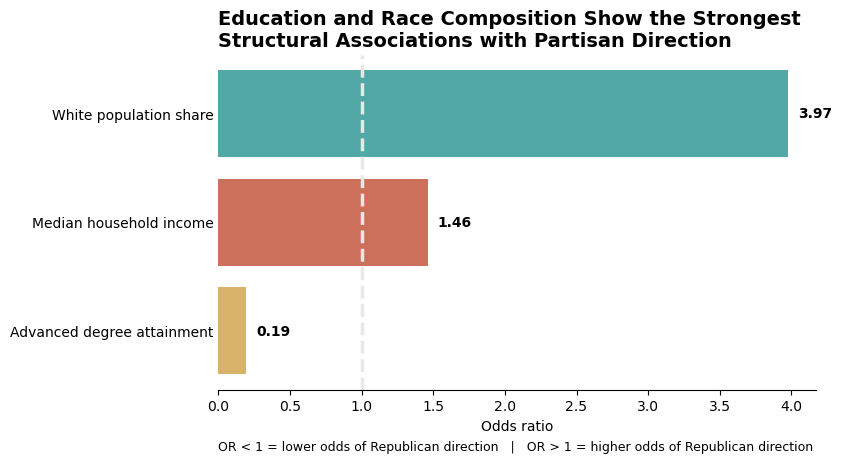

In [7]:
# Figure 1 — Structural odds ratios

import matplotlib.pyplot as plt

# Established project palette
gold = "#D8B26A"
silver = "#E8E9E4"
coral = "#CC6F5B"
teal = "#52A7A7"

structural_plot = coefficient_results[
    coefficient_results["feature"].isin([
        "advanced_degree_pct",
        "median_income",
        "white_pct"
    ])
].copy()

label_map = {
    "advanced_degree_pct": "Advanced degree attainment",
    "median_income": "Median household income",
    "white_pct": "White population share"
}

structural_plot["label"] = structural_plot["feature"].map(label_map)

order = [
    "Advanced degree attainment",
    "Median household income",
    "White population share"
]

structural_plot["label"] = pd.Categorical(
    structural_plot["label"],
    categories=order,
    ordered=True
)

structural_plot = structural_plot.sort_values("label")

# Use only the established palette
bar_colors = [gold, coral, teal]

fig, ax = plt.subplots(figsize=(8.5, 4.8))

bars = ax.barh(
    structural_plot["label"],
    structural_plot["odds_ratio"],
    color=bar_colors
)

# OR = 1 reference line
ax.axvline(
    1,
    color=silver,
    linewidth=2.5,
    linestyle="--"
)

for bar, value in zip(bars, structural_plot["odds_ratio"]):
    ax.text(
        bar.get_width() + 0.07,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Education and Race Composition Show the Strongest\n"
    "Structural Associations with Partisan Direction",
    loc="left",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Odds ratio")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", length=0)

ax.text(
    0.0,
    -0.18,
    "OR < 1 = lower odds of Republican direction   |   OR > 1 = higher odds of Republican direction",
    transform=ax.transAxes,
    fontsize=9
)

plt.tight_layout()
plt.show()

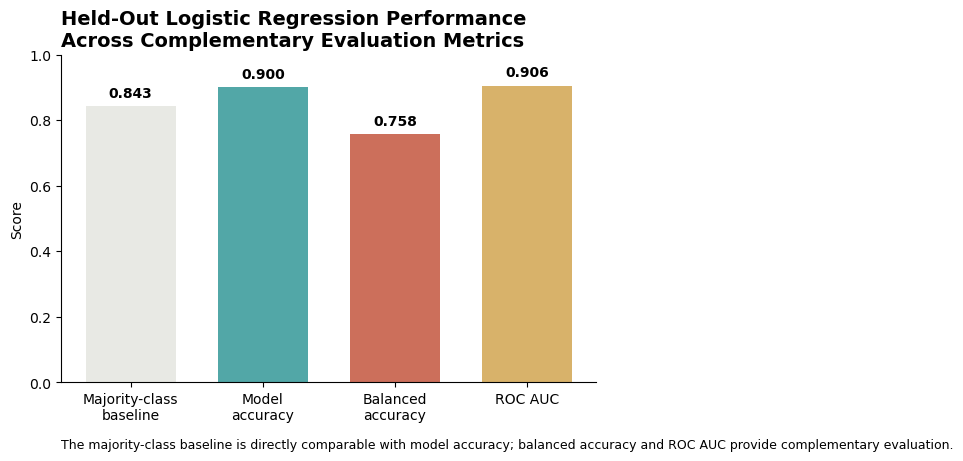

In [8]:
# Figure 2 — Held-out model performance

performance_df = pd.DataFrame({
    "Metric": [
        "Majority-class\nbaseline",
        "Model\naccuracy",
        "Balanced\naccuracy",
        "ROC AUC"
    ],
    "Score": [
        majority_baseline_accuracy,
        test_accuracy,
        test_balanced_accuracy,
        test_roc_auc
    ]
})

# Same established project palette
bar_colors = [
    silver,
    teal,
    coral,
    gold
]

fig, ax = plt.subplots(figsize=(8.5, 4.8))

bars = ax.bar(
    performance_df["Metric"],
    performance_df["Score"],
    color=bar_colors,
    width=0.68
)

for bar, value in zip(bars, performance_df["Score"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.018,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_ylim(0, 1.0)

ax.set_title(
    "Held-Out Logistic Regression Performance\n"
    "Across Complementary Evaluation Metrics",
    loc="left",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Score")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.0,
    -0.20,
    "The majority-class baseline is directly comparable with model accuracy; balanced accuracy and ROC AUC provide complementary evaluation.",
    transform=ax.transAxes,
    fontsize=9
)

plt.tight_layout()
plt.show()

### Visual Interpretation

The structural odds-ratio figure reinforces the earlier capstone results. Advanced-degree attainment is associated with substantially lower odds of Republican direction, while White population share is associated with substantially higher odds. Median income shows a smaller positive association.

The model exceeded the majority-class accuracy baseline, reaching 0.900 accuracy compared with 0.843 for the baseline. Balanced accuracy of 0.758 and ROC AUC of 0.906 provide complementary evidence that performance was not driven solely by the dominant Republican-direction class. However, Democratic-direction recall was substantially lower than Republican-direction recall (0.550 versus 0.965), showing that classification performance remained asymmetric.

## Week 4 Conclusion

The strongest Week 4 findings were largely consistent with the earlier capstone analysis. I expected advanced-degree attainment and White population share to remain important because both had repeatedly emerged as strong predictors of vote margin in earlier models. The positive median-income association was less expected, particularly after controlling for education, race composition, rural-urban geography, and election year.

The logistic model also revealed an important limitation: classification was much stronger for Republican-direction observations than for Democratic-direction observations. In addition, converting `vote_margin` into a binary outcome removes information about how strongly a county leans in either direction. Logistic regression therefore complements rather than replaces the continuous vote-margin analysis or the separate `pol_intensity` measure.

These results remain consistent with the broader capstone premise that political polarization reflects structural conditions rather than a single isolated factor. Prior work used in the capstone similarly frames polarization as connected to broader institutional and economic structures rather than as a purely short-term electoral phenomenon.

**AI assistance:** ChatGPT was used to support code organization, model interpretation, metric selection, and visualization refinement. All model choices, outputs, interpretations, and final conclusions were reviewed against the notebook results.